Importing Libraries

In [103]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [111]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [112]:
# Path to training images
image_path = "/Users/tanzimashaikh/Computer Vision/ASS_3/final_processed_data 2/train"

# Transformation for DCGAN
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  
])


In [113]:
# Load dataset
dataset = datasets.ImageFolder(root=image_path, transform=transform)

# Create dataloader (batch size = 64 for faster training)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)


In [114]:
#  Check shape of one batch
images, _ = next(iter(dataloader))
print("Batch shape:", images.shape)  

Batch shape: torch.Size([64, 3, 64, 64])


In [115]:
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils


Generator

In [106]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, features_g=64):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()  # Output in range [-1, 1]
        )

    def forward(self, x):
        return self.net(x)


In [116]:
z_dim = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen = Generator(z_dim=z_dim).to(device)

# Test output shape
noise = torch.randn(16, z_dim, 1, 1).to(device)
fake_images = gen(noise)
print("Generated image batch shape:", fake_images.shape)  


Generated image batch shape: torch.Size([16, 3, 64, 64])


In [118]:
print("Batch shape:", images.shape)


Batch shape: torch.Size([64, 3, 64, 64])


Discriminator

In [119]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, features_d=64):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x 3 x 64 x 64
            nn.Conv2d(img_channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # Outputs a probability
        )

    def forward(self, x):
        return self.net(x)


In [120]:
disc = Discriminator().to(device)
out = disc(fake_images) 
print("Discriminator output shape:", out.shape)  


Discriminator output shape: torch.Size([16, 1, 1, 1])


Training Loop

In [122]:
import importlib.util

package_name = "torch_fidelity"
is_installed = importlib.util.find_spec(package_name) is not None

print(f"{package_name} installed:", is_installed)


torch_fidelity installed: True


In [124]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import os
from tqdm import tqdm

# ====== Settings ======
z_dim = 100
epochs = 50
batch_size = 64
lr = 2e-4
beta1 = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====== Paths ======
train_folder = "/Users/tanzimashaikh/Computer Vision/ASS_3/final_processed_data 2/train"
save_img_folder = "generated_images"
checkpoint_folder = "checkpoints"
os.makedirs(save_img_folder, exist_ok=True)
os.makedirs(checkpoint_folder, exist_ok=True)

# ====== Transforms & Dataloader ======
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
dataset = datasets.ImageFolder(train_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ====== Generator & Discriminator ======
# Define your Generator and Discriminator classes before this block
gen = Generator(z_dim).to(device)
disc = Discriminator().to(device)

# ====== Optimizers & Loss ======
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(beta1, 0.999))
criterion = nn.BCELoss()
fixed_noise = torch.randn(16, z_dim, 1, 1).to(device)

# ====== Training Loop ======
print("\n Starting DCGAN Training...\n")
for epoch in range(epochs):
    for real, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        real = real.to(device)
        cur_batch_size = real.size(0)

        # === Discriminator Training ===
        noise = torch.randn(cur_batch_size, z_dim, 1, 1, device=device)
        fake = gen(noise)

        lossD_real = criterion(disc(real).view(-1), torch.ones(cur_batch_size, device=device))
        lossD_fake = criterion(disc(fake.detach()).view(-1), torch.zeros(cur_batch_size, device=device))
        lossD = lossD_real + lossD_fake

        opt_disc.zero_grad()
        lossD.backward()
        opt_disc.step()

        # === Generator Training ===
        output = disc(fake).view(-1)
        lossG = criterion(output, torch.ones_like(output))

        opt_gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    # === Save preview images ===
    with torch.no_grad():
        preview = gen(fixed_noise)
        preview = (preview + 1) / 2
        utils.save_image(preview, f"{save_img_folder}/epoch_{epoch+1}_preview.png", nrow=4)

    # === Save checkpoints every 10 epochs ===
    if (epoch + 1) % 10 == 0:
        torch.save(gen.state_dict(), f"{checkpoint_folder}/gen_epoch{epoch+1}.pth")
        torch.save(disc.state_dict(), f"{checkpoint_folder}/disc_epoch{epoch+1}.pth")
        print(f" Checkpoint saved at epoch {epoch+1}")

# ====== Final Save ======
torch.save(gen.state_dict(), "dcgan_generator_final.pth")
print("\n Training Done! Final generator saved as 'dcgan_generator_final.pth'")



 Starting DCGAN Training...



Epoch 10/50: 100%|██████████| 291/291 [05:49<00:00,  1.20s/it]


 Checkpoint saved at epoch 10


Epoch 20/50: 100%|██████████| 291/291 [05:37<00:00,  1.16s/it]


 Checkpoint saved at epoch 20


...

 Checkpoint saved at epoch 30


Epoch 40/50: 100%|██████████| 291/291 [05:31<00:00,  1.14s/it]


 Checkpoint saved at epoch 40


Epoch 50/50: 100%|██████████| 291/291 [05:31<00:00,  1.14s/it]

 Checkpoint saved at epoch 50

 Training Done! Final generator saved as 'dcgan_generator_final.pth'


In [136]:
# Load Trained Generator 
gen = Generator(z_dim=100).to(device)
gen.load_state_dict(torch.load("dcgan_generator_final.pth", map_location=device))
gen.eval()


/var/folders/nw/sm20lhh15mg_qnk_zd6sdzbr0000gn/T/ipykernel_9098/861956145.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen.load_state_dict(torch.load("dcgan_generator

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

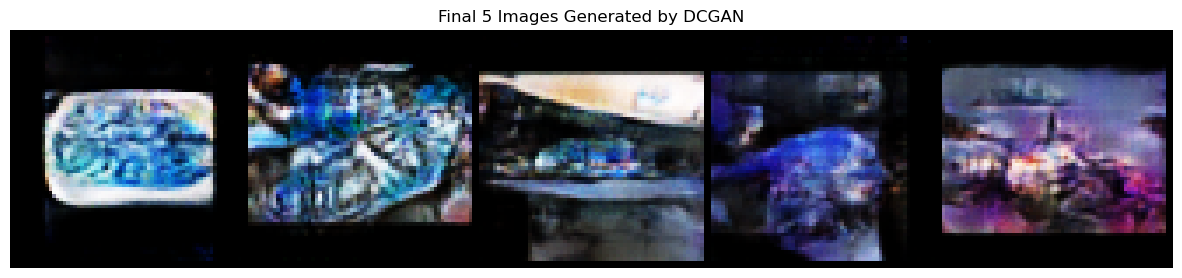

In [137]:
import os
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Created output folder 
output_dir = "final_dcgan_images"
os.makedirs(output_dir, exist_ok=True)

# Generate 5 fake images 
noise = torch.randn(5, 100, 1, 1, device=device)
gen.eval()
with torch.no_grad():
    fake_images = gen(noise).detach().cpu()

# Save the images into the folder 
for i in range(5):
    img = (fake_images[i] + 1) / 2  
    vutils.save_image(img, os.path.join(output_dir, f"img_{i+1}.png"))

# Optional: Display in notebook 
grid = vutils.make_grid(fake_images, nrow=5, normalize=True)
plt.figure(figsize=(15, 5))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Final 5 Images Generated by DCGAN")
plt.show()


In [16]:
!ls


DCGAN-Model.ipynb         dcgan try.ipynb           final_processed_data 2
DCGAN_Model.ipynb         dcgan_generator_final.pth generated_images
cGAN Model.ipynb          final_cgan_outputs        old data 
checkpoints               final_dcgan_images        real_images_folder


In [17]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

real_data_path = "final_processed_data 2/train"

# Check if path exists and list images
if not os.path.exists(real_data_path):
    print("Dataset path does not exist.")
else:
    files = os.listdir(real_data_path)
    print(f" Path found. Number of items in folder: {len(files)}")
    print("Sample files:", files[:5])


 Path found. Number of items in folder: 5
Sample files: ['.DS_Store', 'outside', 'inside', 'food', 'drink']


In [18]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

real_dataset = datasets.ImageFolder(root=real_data_path, transform=transform)
real_dataloader = DataLoader(real_dataset, batch_size=32, shuffle=True)


In [19]:
import torchvision.transforms.functional as TF

real_img_folder = "real_images_folder"
os.makedirs(real_img_folder, exist_ok=True)

saved = 0
max_to_save = 50  

for batch_idx, (real_images, _) in enumerate(real_dataloader):
    for i in range(real_images.size(0)):
        if saved >= max_to_save:
            break
        img = TF.to_pil_image(real_images[i])
        img.save(f"{real_img_folder}/real_{batch_idx}_{i}.png")
        saved += 1
    if saved >= max_to_save:
        break

print(f" Saved {saved} real images to '{real_img_folder}'")


 Saved 50 real images to 'real_images_folder'


In [20]:
print(" Files in real_images_folder:", os.listdir("real_images_folder")[:5])
print(" Total images saved:", len(os.listdir("real_images_folder")))


 Files in real_images_folder: ['real_0_29.png', 'real_0_15.png', 'real_0_14.png', 'real_0_28.png', 'real_0_16.png']
 Total images saved: 50


FID

In [21]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision import transforms
from PIL import Image
import torch
import os


In [22]:
def load_images_from_folder(folder):
    images = []
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor()
    ])
    for filename in os.listdir(folder):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert('RGB')
            img = transform(img)
            images.append(img)
    return torch.stack(images) if images else torch.empty(0)


In [23]:
real_imgs = load_images_from_folder("real_images_folder")
fake_imgs = load_images_from_folder("final_dcgan_images")

# Check if both sets are non-empty
print(f"Real images shape: {real_imgs.shape}")
print(f"Fake images shape: {fake_imgs.shape}")


Real images shape: torch.Size([50, 3, 299, 299])
Fake images shape: torch.Size([10, 3, 299, 299])


In [24]:
fid = FrechetInceptionDistance(normalize=True)
fid.update(real_imgs, real=True)
fid.update(fake_imgs, real=False)
fid_score = fid.compute().item()

print(f" Frechet Inception Distance (FID): {fid_score:.2f}")


 Frechet Inception Distance (FID): 345.61


In [25]:
iscore = InceptionScore(normalize=True)
iscore.update(fake_imgs)
is_mean, is_std = iscore.compute()

print(f" Inception Score: {is_mean:.2f} ± {is_std:.2f}")


/opt/anaconda3/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


 Inception Score: 1.00 ± 0.00


In [29]:
import os
print(os.listdir())


['old data ', 'dcgan_generator_final.pth', '.DS_Store', 'generated_images', 'checkpoints', 'cGAN Model.ipynb', 'final_dcgan_images', 'DCGAN_Model.ipynb', 'DCGAN-Model.ipynb', 'final_cgan_outputs', 'dcgan try.ipynb', '.ipynb_checkpoints', 'final_processed_data 2', 'real_images_folder']


In [30]:
import torch
import torch.nn as nn
import torchvision.utils as vutils
import os

# Generator Class 
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Load Generator Weights 
generator = Generator()
generator.load_state_dict(torch.load("checkpoints/gen_epoch50.pth", map_location=torch.device("cpu")))
generator.eval()

# Make output folder 
output_dir = "final_dcgan_images"
os.makedirs(output_dir, exist_ok=True)

#  Generate and save 5 images 
for i in range(5):
    noise = torch.randn(1, 100, 1, 1)  
    with torch.no_grad():
        fake_image = generator(noise)
    vutils.save_image(fake_image, os.path.join(output_dir, f"gen_img_{i+1}.png"), normalize=True)

print(" 5 images saved in:", output_dir)


 5 images saved in: final_dcgan_images


/var/folders/nw/sm20lhh15mg_qnk_zd6sdzbr0000gn/T/ipykernel_38323/3728780132.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load("checkp

In [31]:
fid = FrechetInceptionDistance(normalize=True)
fid.update(real_imgs, real=True)
fid.update(fake_imgs, real=False)
fid_score = fid.compute().item()

print(f" Frechet Inception Distance (FID): {fid_score:.2f}")


 Frechet Inception Distance (FID): 345.61


In [32]:
iscore = InceptionScore(normalize=True)
iscore.update(fake_imgs)
is_mean, is_std = iscore.compute()

print(f" Inception Score: {is_mean:.2f} ± {is_std:.2f}")


 Inception Score: 1.00 ± 0.00
